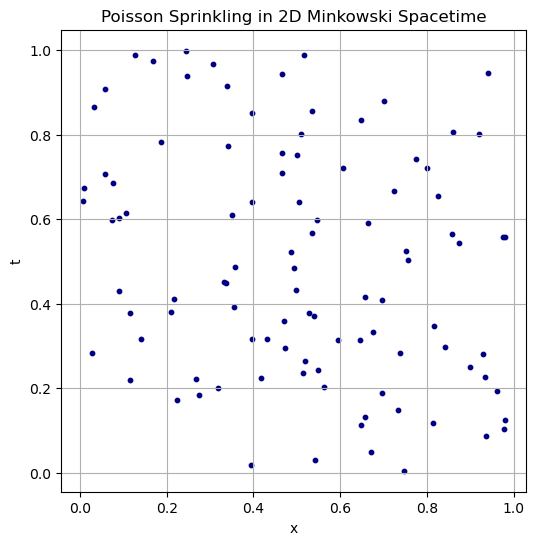

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Sprinkle N points randomly in 2D Minkowski spacetime
N = 100
t = np.random.rand(N)  # time coordinates
x = np.random.rand(N)  # space coordinates

points = list(zip(t, x))

# Visualize the sprinkling
plt.figure(figsize=(6, 6))
plt.scatter(x, t, s=10, color='navy')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Poisson Sprinkling in 2D Minkowski Spacetime')
plt.grid(True)
plt.show()


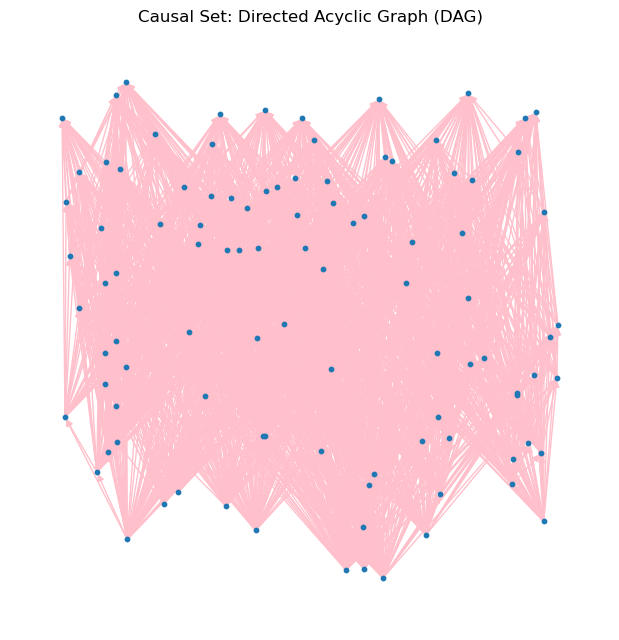

In [16]:
import networkx as nx

# Step 2: Create causal links using the lightcone condition
G = nx.DiGraph()

for i in range(N):
    G.add_node(i, pos=(x[i], t[i]))  # assign coordinates as node attributes
    for j in range(N):
        if t[j] > t[i]:  # future condition
            if (t[j] - t[i])**2 >= (x[j] - x[i])**2:  # inside lightcone
                G.add_edge(i, j)  # causal link from i to j

# Plot the causal set graph
plt.figure(figsize=(6, 6))
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, node_size=10, arrows=True, edge_color='pink')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Causal Set: Directed Acyclic Graph (DAG)')
plt.grid(True)
plt.show()


In [8]:

from collections import Counter

# Step 3: Count k-element intervals
max_k = 4
interval_counts = Counter()

nodes = list(G.nodes)

for i in range(len(nodes)):
    for j in range(len(nodes)):
        if i == j:
            continue
        if nx.has_path(G, i, j):  # if i causally precedes j
            # find all nodes between i and j
            interval = [k for k in nodes if k != i and k != j
                        and nx.has_path(G, i, k) and nx.has_path(G, k, j)]
            k_size = len(interval)
            if k_size <= max_k:
                interval_counts[k_size] += 1

# Display interval statistics
for k in range(max_k + 1):
    print(f"Number of intervals with {k} elements: {interval_counts[k]}")


Number of intervals with 0 elements: 323
Number of intervals with 1 elements: 235
Number of intervals with 2 elements: 176
Number of intervals with 3 elements: 158
Number of intervals with 4 elements: 133


In [9]:
# Step 4: Compute scalar curvature estimate from interval counts

coefficients = {
    0: -2,
    1: 4,
    2: -2,
    3: 4/3,
    4: -0.5
}

l_squared = 1.0  # set discreteness scale to 1 for now

R = 0  # total curvature estimate

for k in range(max_k + 1):
    R += coefficients.get(k, 0) * interval_counts[k]

R /= l_squared  # scale appropriately

print(f"\nEstimated BD Curvature Action: {R}")



Estimated BD Curvature Action: 86.16666666666666
